# Calculate Scene NDVI  

In this notebook, I develop a function that takes sentinel-2 observations, a given geometry (e.g. Phoenix Park boundary) in EPSG:32629 crs, and returns a mean_ndvi score per scene (vegetation pixels only) as well as an array (xarray.DataArray) conatining a 2-D NDVI spatial raster for that scene.  
I also do some further data exploration (investigating SCL codes on cloudier scenes) and try to optimise the scene loading to reduce the time the function takes.

In [ ]:
# pseudocode for function:

def calculate_scene_ndvi(item, park_utm):
    # load three bands (NIR, Red, SCL) from STAC item
    # crop to park bounding box
    # mask to park geometry
    # keep vegetation pixels
    # calculate NDVI per pixel
    # calculate mean NDVI
    # return mean NDVI

Fill in the function using code from notebook 1:

In [30]:
# Load packages
import geopandas as gpd
from odc.stac import load
#import rioxarray
import numpy as np
import pystac_client
import planetary_computer
import xarray as xr


In [8]:
def calculate_scene_ndvi(item, park_utm):
    # sign item:
    item = planetary_computer.sign(item)
    # load three bands (NIR, Red, SCL) from STAC item
    ds = load(
        [item],
        bands=["B04", "B08", "SCL"],
        crs="EPSG:32629",
        resolution=10,
    )

    # crop to park bounding box
    xmin, ymin, xmax, ymax = park_utm.total_bounds
    park_bbox = ds.sel(
        x = slice(xmin, xmax),
        y = slice(ymax, ymin)
    )

    # mask to park geometry
    park_bbox = park_bbox.rio.write_crs("EPSG:32629")
    park_masked = park_bbox.rio.clip(
        park_utm.geometry,
        park_utm.crs, 
        drop=False 
    )

    # keep vegetation pixels
    vegetation_mask = park_masked.SCL==4

    # calculate NDVI per pixel
    ndvi = (
        (park_masked.B08 - park_masked.B04)
        / (park_masked.B08 + park_masked.B04)
    )
    ndvi_veg = ndvi.where(vegetation_mask)
    #for now just return ndvi_veg
    return ndvi_veg

    # calculate mean NDVI
    # return mean NDVI

Test the function thus far

In [4]:
# Get park_utm
parks = gpd.read_file('../data/dcc_parks_strategy2016_park_classification.geojson')
park = parks[parks.Name.str.contains('Phoenix')].copy()
park_utm = park.to_crs('EPSG:32629')

In [5]:
# Get item from STAC catalogue
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1'
    )

search = catalog.search(
    collections = ['sentinel-2-l2a'],
    bbox = park.total_bounds,
    datetime='2026-07-01/2026-07-31'
)

items = list(search.items())

item = items[13]

In [10]:
test_ndvi = calculate_scene_ndvi(item, park_utm)

In [11]:
test_ndvi.mean().item()

0.5580050945281982

Same result as in notebook 1, so the function works so far!  

Now let's add the final steps to return the mean ndvi from the funtion

In [32]:
def calculate_scene_ndvi(item, park_utm):
    # sign item:
    item = planetary_computer.sign(item)
    # load three bands (NIR, Red, SCL) from STAC item
    ds = load(
        [item],
        bands=["B04", "B08", "SCL"],
        crs="EPSG:32629",
        resolution=10,
    )

    # crop to park bounding box
    xmin, ymin, xmax, ymax = park_utm.total_bounds
    park_bbox = ds.sel(
        x = slice(xmin, xmax),
        y = slice(ymax, ymin)
    )

    # mask to park geometry
    park_bbox = park_bbox.rio.write_crs("EPSG:32629")
    park_masked = park_bbox.rio.clip(
        park_utm.geometry,
        park_utm.crs, 
        drop=False 
    )

    # keep vegetation pixels
    vegetation_classes = [4]
    vegetation_mask = park_masked.SCL.isin(vegetation_classes)

    # calculate NDVI per pixel
    ndvi = (
        (park_masked.B08 - park_masked.B04)
        / (park_masked.B08 + park_masked.B04)
    )
    ndvi_veg = ndvi.where(vegetation_mask)

    # calculate mean NDVI
    ndvi_mean = ndvi_veg.mean().item()

    # return mean NDVI
    return ndvi_mean

In [33]:
test_ndvi = calculate_scene_ndvi(item, park_utm)
test_ndvi

0.5580050945281982

The function is ready to apply to multiple scenes, but let's start by searching only for scenes with < 50% cloud cover

In [12]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=park.total_bounds,
    datetime="2026-07-01/2026-07-31",
    query={"eo:cloud_cover": {"lt": 50}},
)

items_2026 = list(search.items())

print(len(items_2026))

8


In [18]:
for item in items_2026:
    print(
        item.datetime.date(),
        item.properties["eo:cloud_cover"]
    )

2026-07-30 34.713548
2026-07-18 29.242787
2026-07-15 19.680642
2026-07-15 24.00787
2026-07-13 34.744766
2026-07-12 2.876604
2026-07-10 28.218237
2026-07-08 0.55251


Note that the cloud_cover property is for the entire rectangular scene - even a relatively highly cloudy scene might give us a clear image within the park boundaries.

In [21]:
for item in items_2026:
    print(item)

<Item id=S2C_MSIL2A_20260730T113321_R080_T29UPV_20260730T150808>
<Item id=S2B_MSIL2A_20260718T114349_R123_T29UPV_20260718T152635>
<Item id=S2A_MSIL2A_20260715T114401_R123_T29UPV_20260715T194209>
<Item id=S2B_MSIL2A_20260715T113319_R080_T29UPV_20260715T141254>
<Item id=S2C_MSIL2A_20260713T114351_R123_T29UPV_20260713T163414>
<Item id=S2A_MSIL2A_20260712T113331_R080_T29UPV_20260712T174812>
<Item id=S2C_MSIL2A_20260710T113321_R080_T29UPV_20260710T150914>
<Item id=S2B_MSIL2A_20260708T114349_R123_T29UPV_20260708T152442>


Let's just take a look at what's going on with SCL in a cloudier scene - does SCL classify cloud pixels?

In [ ]:
# Get the cloudiest item from items_2026
cloudier_item = max(
    items_2026,
    key=lambda item: item.properties["eo:cloud_cover"]
)

In [24]:
cloudier_item.properties['eo:cloud_cover']

34.744766

In [25]:
# Load the scene (with our 3 required bands)
cloudier_item = planetary_computer.sign(cloudier_item)

ds_cloudier = load(
    [cloudier_item],
    bands=["B04", "B08", "SCL"],
    crs="EPSG:32629",
    resolution=10,
)

In [29]:
# Crop it to the park boundaries
xmin, ymin, xmax, ymax = park_utm.total_bounds

park_bbox_cloudier = ds_cloudier.sel(
    x=slice(xmin, xmax),
    y=slice(ymax, ymin)
)

park_bbox_cloudier = park_bbox_cloudier.rio.write_crs("EPSG:32629")

park_masked_cloudier = park_bbox_cloudier.rio.clip(
    park_utm.geometry,
    park_utm.crs,
    drop=False
)

In [30]:
# Inspect the SCL classses
np.unique(park_masked_cloudier.SCL.values)

array([ 4.,  5.,  6.,  7., 10., nan], dtype=float32)

In [31]:
# How many pixels belong to each class?
values, counts = np.unique(
    park_masked_cloudier.SCL.values[~np.isnan(park_masked_cloudier.SCL.values)],
    return_counts=True
)

dict(zip(values.astype(int), counts))

{np.int64(4): np.int64(65300),
 np.int64(5): np.int64(2213),
 np.int64(6): np.int64(4),
 np.int64(7): np.int64(36),
 np.int64(10): np.int64(404)}

SCL	Meaning	Pixels  
4	Vegetation	65,300  
5	Not vegetated	2,213  
6	Water	4  
7	Unclassified	36  
10	Thin cirrus	404

Good - so despite the scene having 34.7% cloud cover, only 404 pixels within the park boundary are classed as clouds

To be extra cautious, let's restrict the search to scenes with <20% cloud cover

In [34]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=park.total_bounds,
    datetime="2026-07-01/2026-07-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items_2026 = list(search.items())

print(len(items_2026))

3


Now apply our function to these 3 items from July 2026

In [35]:
results_2026 = []

for item in items_2026_clear:
    mean_ndvi = calculate_scene_ndvi(item, park_utm)

    results_2026.append({
        "date": item.datetime.date(),
        "cloud_cover": item.properties["eo:cloud_cover"],
        "mean_ndvi": mean_ndvi
    })

It's worrying that for only 3 scenes, the runtime is already 2m 43s.  
Let's try to optimise that later by loading smaller scenes (as we only need a fraction of the 10980*10980 pixels from the sentinel-2 scene for each item).

In [36]:
results_2026

[{'date': datetime.date(2026, 7, 15),
  'cloud_cover': 19.680642,
  'mean_ndvi': 0.5459466576576233},
 {'date': datetime.date(2026, 7, 12),
  'cloud_cover': 2.876604,
  'mean_ndvi': 0.5242596864700317},
 {'date': datetime.date(2026, 7, 8),
  'cloud_cover': 0.55251,
  'mean_ndvi': 0.5580050945281982}]

Now we need to aggregate these mean values into one yearly July value. Let's use the median as it is less sensitive to outliers (e.g. particularly cloudy days)

In [37]:
july_2026_ndvi = np.median(
    [result["mean_ndvi"] for result in results_2026]
)

july_2026_ndvi

np.float64(0.5459466576576233)

Ok, now let's try to load some older Sentinel-2 data, from 2016

In [50]:
search_2016 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=park.total_bounds,
    datetime="2016-07-01/2016-07-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items_2016 = list(search_2016.items())

print(len(items_2016))

1


In [51]:
for item in items_2016:
    print(
        item.datetime.date(),
        item.properties["eo:cloud_cover"],
        item.id
    )

2016-07-18 18.377901 S2A_MSIL2A_20160718T115402_R023_T29UPV_20210212T054319


Make sure the 2016 data contain everything we need (Sentinel-2 started in 2015, and some of the processing, e.g. SCL, B04, B08) might have been done only later

In [52]:
item_2016 = items_2016[0]

print(item_2016.properties["proj:code"])
print(item_2016.properties["s2:processing_baseline"])
print(item_2016.properties["eo:cloud_cover"])

EPSG:32629
02.12
18.377901


In [53]:
print(item_2016.assets.keys())

dict_keys(['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'preview', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview'])


Now let's test our function on the 2016 scene

In [54]:
ndvi_2016 = calculate_scene_ndvi(
    item_2016,
    park_utm
)

print(ndvi_2016)

nan


That;s not great - let's inspect the data more closely

In [55]:
item_2016 = planetary_computer.sign(item_2016)

ds_2016 = load(
    [item_2016],
    bands=["B04", "B08", "SCL"],
    crs="EPSG:32629",
    resolution=10,
)

In [56]:
xmin, ymin, xmax, ymax = park_utm.total_bounds

park_bbox_2016 = ds_2016.sel(
    x=slice(xmin, xmax),
    y=slice(ymax, ymin)
)

park_bbox_2016 = park_bbox_2016.rio.write_crs("EPSG:32629")

park_masked_2016 = park_bbox_2016.rio.clip(
    park_utm.geometry,
    park_utm.crs,
    drop=False
)

In [57]:
np.unique(
    park_masked_2016.SCL.values[
        ~np.isnan(park_masked_2016.SCL.values)
    ]
)

array([0.], dtype=float32)

In [58]:
np.unique(ds_2016.SCL.values)

array([ 0.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 11.], dtype=float32)

In [59]:
ds_2016.SCL.isnull().sum().item()

0

So the scene contains usable pixels with SCL value of 4, but for some reason we're not getting those pixels in the scene filtered to the park boundary.  
Let's inspect the spatial extent of the 2016 dataset:

In [60]:
print(
    ds_2016.x.min().item(),
    ds_2016.x.max().item(),
    ds_2016.y.min().item(),
    ds_2016.y.max().item()
)

600005.0 709795.0 5890205.0 5999995.0


In [61]:
# Compare to the park bounds
print(park_utm.total_bounds)

[ 675929.7255781  5914124.74473145  680050.29649826 5916874.43343763]


So the park fits inside the extent of the scene...  
Let's check the SCL values after cropping:

In [62]:
np.unique(park_bbox_2016.SCL.values)

array([0.], dtype=float32)

ok, so rio.clip is not the problem. We lose our SCL classes during the .sel() crop...  
Let's look at the 2016 grid around the park:

In [63]:
print(ds_2016.x.sel(x=xmin, method="nearest").item())
print(ds_2016.x.sel(x=xmax, method="nearest").item())

print(ds_2016.y.sel(y=ymin, method="nearest").item())
print(ds_2016.y.sel(y=ymax, method="nearest").item())

675925.0
680055.0
5914125.0
5916875.0


And the direction of the axes:

In [64]:
print(ds_2016.x.values[:3])
print(ds_2016.x.values[-3:])

print(ds_2016.y.values[:3])
print(ds_2016.y.values[-3:])

[600005. 600015. 600025.]
[709775. 709785. 709795.]
[5999995. 5999985. 5999975.]
[5890225. 5890215. 5890205.]


Everything looks fine...  
Let's look at the other bands (B04, B08) to see if the problem is just with SCL

In [65]:
print(
    park_bbox_2016.B04.min().item(),
    park_bbox_2016.B04.max().item()
)

print(
    park_bbox_2016.B08.min().item(),
    park_bbox_2016.B08.max().item()
)

0.0 0.0
0.0 0.0


In [66]:
print(
    np.unique(park_bbox_2016.SCL.values)
)

[0.]


Let's see if the scene acually contains valid data near the park

In [67]:
print(ds_2016.B04.min().item())
print(ds_2016.B04.max().item())

0.0
16376.0


In [68]:
nonzero = ds_2016.B04 > 0

ys, xs = np.where(nonzero.values[0])

print(xs.min(), xs.max())
print(ys.min(), ys.max())

0 1445
0 4623


Ok, so not all of the 2016 scene is populated with datapoints. Let's try 2017 or 2018 instead.

In [13]:
search_2017 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=park.total_bounds,
    datetime="2017-07-01/2017-07-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items_2017 = list(search_2017.items())

print(len(items_2017))

for item in items_2017:
    print(
        item.datetime.date(),
        item.properties["eo:cloud_cover"],
        item.id
    )

2
2017-07-17 0.190993 S2A_MSIL2A_20170717T113321_R080_T29UPV_20210210T101839
2017-07-12 19.282658 S2B_MSIL2A_20170712T113319_R080_T29UPV_20210210T080149


In [75]:
item_2017 = items_2017[0]

ndvi_2017 = calculate_scene_ndvi(
    item_2017,
    park_utm
)

print(ndvi_2017)

0.8295615315437317


In [78]:
for i, item in enumerate(items_2017):
    print(
        i,
        item.datetime.date(),
        item.properties["eo:cloud_cover"],
        item.id
    )

0 2017-07-17 0.190993 S2A_MSIL2A_20170717T113321_R080_T29UPV_20210210T101839
1 2017-07-12 19.282658 S2B_MSIL2A_20170712T113319_R080_T29UPV_20210210T080149


In [79]:
ndvi_2017_1 = calculate_scene_ndvi(
    items_2017[1],
    park_utm
)

print(ndvi_2017_1)

0.7710665464401245


In [81]:
july_2017_ndvi = np.median([
    ndvi_2017,
    ndvi_2017_1
])

print(july_2017_ndvi)

0.8003140389919281


Ok, 2017 seems to work, so let's restrict our analysis to the past 10 years (2017 - 2026).  
Increase cloud_cover filter to 50% because 20% gives some years with 0 scenes

In [83]:
results = []

for year in range (2017, 2026):
    search = catalog.search(
        collections=['sentinel-2-l2a'],
        bbox=park.total_bounds,
        datetime=f'{year}-07-01/{year}-07-31',
        query={'eo:cloud_cover': {'lt':50}}
    )

    items = list(search.items())

    print(year, len(items))

2017 3
2018 2
2019 2
2020 0
2021 4
2022 0
2023 2
2024 1
2025 3


Even at 50% cloud cover filter, 2020 and 2022 have 0 qualifying scenes. Let's investigate 2020:

In [85]:
search_2020 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=park.total_bounds,
    datetime="2020-07-01/2020-07-31",
)

items_2020 = list(search_2020.items())

print(len(items_2020))

for item in items_2020:
    print(
        item.datetime.date(),
        item.properties["eo:cloud_cover"],
        item.id
    )

13
2020-07-31 98.010061 S2A_MSIL2A_20200731T113331_R080_T29UPV_20200818T064627
2020-07-29 99.380312 S2B_MSIL2A_20200729T114349_R123_T29UPV_20200818T014753
2020-07-26 70.036764 S2B_MSIL2A_20200726T113319_R080_T29UPV_20200817T161321
2020-07-24 99.866863 S2A_MSIL2A_20200724T114351_R123_T29UPV_20200817T084713
2020-07-21 57.171806 S2A_MSIL2A_20200721T113321_R080_T29UPV_20200816T232913
2020-07-19 76.944835 S2B_MSIL2A_20200719T114349_R123_T29UPV_20200816T184653
2020-07-16 91.386915 S2B_MSIL2A_20200716T113319_R080_T29UPV_20200816T094802
2020-07-14 82.332611 S2A_MSIL2A_20200714T114351_R123_T29UPV_20200919T001923
2020-07-11 92.936763 S2A_MSIL2A_20200711T113321_R080_T29UPV_20200919T001926
2020-07-09 83.179827 S2B_MSIL2A_20200709T114349_R123_T29UPV_20200912T152639
2020-07-06 80.784167 S2B_MSIL2A_20200706T113319_R080_T29UPV_20200825T113906
2020-07-04 99.718945 S2A_MSIL2A_20200704T114351_R123_T29UPV_20200909T133405
2020-07-01 87.178331 S2A_MSIL2A_20200701T113321_R080_T29UPV_20200824T193132


21/07/2020 has the lowest cloud cover at 57% (for the entire scene) - let's look at how many pixels inside the park boundary are classified as clouds on this date:

In [86]:
item_2020_test = next(
    item for item in items_2020
    if item.datetime.date().isoformat() == "2020-07-21"
)

In [87]:
print(item_2020_test.id)
print(item_2020_test.properties["eo:cloud_cover"])

S2A_MSIL2A_20200721T113321_R080_T29UPV_20200816T232913
57.171806


In [89]:
item_2020_test = planetary_computer.sign(item_2020_test)

ds_2020_test = load(
    [item_2020_test],
    bands=["B04", "B08", "SCL"],
    crs="EPSG:32629",
    resolution=10,
)

In [90]:
xmin, ymin, xmax, ymax = park_utm.total_bounds

park_bbox_2020 = ds_2020_test.sel(
    x=slice(xmin, xmax),
    y=slice(ymax, ymin)
)

In [91]:
park_bbox_2020 = park_bbox_2020.rio.write_crs("EPSG:32629")

park_masked_2020 = park_bbox_2020.rio.clip(
    park_utm.geometry,
    park_utm.crs,
    drop=False
)

In [92]:
values, counts = np.unique(
    park_masked_2020.SCL.values[
        ~np.isnan(park_masked_2020.SCL.values)
    ],
    return_counts=True
)

dict(zip(values.astype(int), counts))

{np.int64(2): np.int64(124),
 np.int64(4): np.int64(4087),
 np.int64(5): np.int64(774),
 np.int64(7): np.int64(17268),
 np.int64(8): np.int64(4332),
 np.int64(9): np.int64(31337),
 np.int64(10): np.int64(10035)}

Solution for now - update the function to return both mean_ndvi and number of vegetation pixels per scene. Set the search cloud_cover filter to be quite broad (60%). Threshold the results later based on actual number of vegetation pixels visible in a scene.

In [93]:
def calculate_scene_ndvi(item, park_utm):
    # sign item:
    item = planetary_computer.sign(item)
    # load three bands (NIR, Red, SCL) from STAC item
    ds = load(
        [item],
        bands=["B04", "B08", "SCL"],
        crs="EPSG:32629",
        resolution=10,
    )

    # crop to park bounding box
    xmin, ymin, xmax, ymax = park_utm.total_bounds
    park_bbox = ds.sel(
        x = slice(xmin, xmax),
        y = slice(ymax, ymin)
    )

    # mask to park geometry
    park_bbox = park_bbox.rio.write_crs("EPSG:32629")
    park_masked = park_bbox.rio.clip(
        park_utm.geometry,
        park_utm.crs, 
        drop=False 
    )

    # keep vegetation pixels
    vegetation_classes = [4]
    vegetation_mask = park_masked.SCL.isin(vegetation_classes)

    # calculate NDVI per pixel
    ndvi = (
        (park_masked.B08 - park_masked.B04)
        / (park_masked.B08 + park_masked.B04)
    )
    ndvi_veg = ndvi.where(vegetation_mask)

    # calculate mean NDVI
    ndvi_mean = ndvi_veg.mean().item()

    # calculate vegetation pixels
    veg_pixels = vegetation_mask.sum().item()

    # return mean NDVI
    return ndvi_mean, veg_pixels

In [94]:
# Test
mean_ndvi, vegetation_pixels = calculate_scene_ndvi(
    items_2017[0],
    park_utm
)

print(mean_ndvi)
print(vegetation_pixels)

0.8295615315437317
65789


Looks good, now let's try it out on the full date range and all scenes with <60% cloud cover

In [96]:
results = []

for year in range(2017, 2027):

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=park.total_bounds,
        datetime=f"{year}-07-01/{year}-07-31",
        query={"eo:cloud_cover": {"lt": 60}},
    )

    items = list(search.items())

    print(f"{year}: {len(items)} scenes")

    for item in items:

        mean_ndvi, vegetation_pixels = calculate_scene_ndvi(
            item,
            park_utm
        )

        results.append({
            "year": year,
            "date": item.datetime.date(),
            "cloud_cover": item.properties["eo:cloud_cover"],
            "mean_ndvi": mean_ndvi,
            "vegetation_pixels": vegetation_pixels,
            "item_id": item.id,
        })

2017: 6 scenes
2018: 4 scenes
2019: 3 scenes
2020: 1 scenes
2021: 4 scenes
2022: 0 scenes
2023: 4 scenes
2024: 3 scenes
2025: 3 scenes
2026: 9 scenes


In [97]:
results

[{'year': 2017,
  'date': datetime.date(2017, 7, 30),
  'cloud_cover': 57.449046,
  'mean_ndvi': nan,
  'vegetation_pixels': 0,
  'item_id': 'S2A_MSIL2A_20170730T114351_R123_T29UPV_20210210T164343'},
 {'year': 2017,
  'date': datetime.date(2017, 7, 27),
  'cloud_cover': 59.607341,
  'mean_ndvi': 0.7790460586547852,
  'vegetation_pixels': 50522,
  'item_id': 'S2A_MSIL2A_20170727T113321_R080_T29UPV_20210210T151155'},
 {'year': 2017,
  'date': datetime.date(2017, 7, 22),
  'cloud_cover': 56.915364,
  'mean_ndvi': 0.7625647187232971,
  'vegetation_pixels': 65428,
  'item_id': 'S2B_MSIL2A_20170722T113319_R080_T29UPV_20210210T125822'},
 {'year': 2017,
  'date': datetime.date(2017, 7, 20),
  'cloud_cover': 48.633645,
  'mean_ndvi': 0.6364783048629761,
  'vegetation_pixels': 15600,
  'item_id': 'S2A_MSIL2A_20170720T114351_R123_T29UPV_20210210T114324'},
 {'year': 2017,
  'date': datetime.date(2017, 7, 17),
  'cloud_cover': 0.190993,
  'mean_ndvi': 0.8295615315437317,
  'vegetation_pixels': 6578

In [98]:
import pandas as pd

df = pd.DataFrame(results)

df = df.sort_values(["year", "date"])

df[[
    "year",
    "date",
    "cloud_cover",
    "mean_ndvi",
    "vegetation_pixels"
]]

,year,date,cloud_cover,mean_ndvi,vegetation_pixels
5,2017,2017-07-12,19.282658,0.771067,41593
4,2017,2017-07-17,0.190993,0.829562,65789
3,2017,2017-07-20,48.633645,0.636478,15600
2,2017,2017-07-22,56.915364,0.762565,65428
1,2017,2017-07-27,59.607341,0.779046,50522
0,2017,2017-07-30,57.449046,NaN,0
9,2018,2018-07-02,0.195562,0.683419,63199
8,2018,2018-07-07,51.467725,0.710790,7759
7,2018,2018-07-10,12.491578,0.668602,55416
6,2018,2018-07-30,54.711801,NaN,0


Let's set a threshold for the number of vegetation pixels required to be included in our analysis - we can classify each scene as high visibility (>= 80% of the max observed vegetation pixel count), moderate visibility (50-80%) and low visibility (<50%)

In [100]:
max_vegetation_pixels = df["vegetation_pixels"].max()

print(max_vegetation_pixels)

65885


In [104]:
df["vegetation_coverage_pc"] = (
    df["vegetation_pixels"] / max_vegetation_pixels * 100
)

In [105]:
df[[
    "year",
    "date",
    "cloud_cover",
    "mean_ndvi",
    "vegetation_pixels",
    "vegetation_coverage_pc"
]]

,year,date,cloud_cover,mean_ndvi,vegetation_pixels,vegetation_coverage_pc
5,2017,2017-07-12,19.282658,0.771067,41593,63.129696
4,2017,2017-07-17,0.190993,0.829562,65789,99.854292
3,2017,2017-07-20,48.633645,0.636478,15600,23.677620
2,2017,2017-07-22,56.915364,0.762565,65428,99.306367
1,2017,2017-07-27,59.607341,0.779046,50522,76.682098
0,2017,2017-07-30,57.449046,NaN,0,0.000000
9,2018,2018-07-02,0.195562,0.683419,63199,95.923200
8,2018,2018-07-07,51.467725,0.710790,7759,11.776580
7,2018,2018-07-10,12.491578,0.668602,55416,84.110192
6,2018,2018-07-30,54.711801,NaN,0,0.000000


In [109]:
bins = [0, 50, 80, 100]

labels = [
    "low (0–50%)",
    "moderate (50–80%)",
    "high (80–100%)"
]

df["coverage_band"] = pd.cut(
    df["vegetation_coverage"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [110]:
df[[
    "year",
    "date",
    "cloud_cover",
    "mean_ndvi",
    "vegetation_pixels",
    "vegetation_coverage",
    "coverage_band"
]]

,year,date,cloud_cover,mean_ndvi,vegetation_pixels,vegetation_coverage,coverage_band
5,2017,2017-07-12,19.282658,0.771067,41593,63.129696,moderate (50–80%)
4,2017,2017-07-17,0.190993,0.829562,65789,99.854292,high (80–100%)
3,2017,2017-07-20,48.633645,0.636478,15600,23.677620,low (0–50%)
2,2017,2017-07-22,56.915364,0.762565,65428,99.306367,high (80–100%)
1,2017,2017-07-27,59.607341,0.779046,50522,76.682098,moderate (50–80%)
0,2017,2017-07-30,57.449046,NaN,0,0.000000,low (0–50%)
9,2018,2018-07-02,0.195562,0.683419,63199,95.923200,high (80–100%)
8,2018,2018-07-07,51.467725,0.710790,7759,11.776580,low (0–50%)
7,2018,2018-07-10,12.491578,0.668602,55416,84.110192,high (80–100%)
6,2018,2018-07-30,54.711801,NaN,0,0.000000,low (0–50%)


# Final function definition  

Updating the function to also return an xarray object containing 2-D spatial raster data of NDVI values for vegetation pixels, in addition to the mean NDVI value and cloud cover.  
Also including the park boundaries in the load function to reduce the loading time (from 10980^2 pixels to ~200*400 pixels)

In [25]:
def calculate_scene_ndvi(item, park_utm):
    # sign item:
    item = planetary_computer.sign(item)

    xmin, ymin, xmax, ymax = park_utm.total_bounds

    # load three bands (NIR, Red, SCL) from STAC item
    ds = load(
        [item],
        bands=["B04", "B08", "SCL"],
        crs="EPSG:32629",
        resolution=10,
        x=(xmin, xmax),
        y=(ymin,ymax)
    )

    # crop to park bounding box
    # xmin, ymin, xmax, ymax = park_utm.total_bounds
    park_bbox = ds.sel(
        x = slice(xmin, xmax),
        y = slice(ymax, ymin)
    )

    # mask to park geometry
    park_bbox = park_bbox.rio.write_crs("EPSG:32629")
    park_masked = park_bbox.rio.clip(
        park_utm.geometry,
        park_utm.crs, 
        drop=False 
    )

    # keep vegetation pixels
    vegetation_classes = [4]
    vegetation_mask = park_masked.SCL.isin(vegetation_classes)

    # calculate NDVI per pixel
    red = park_masked.B04.where(vegetation_mask)
    nir = park_masked.B08.where(vegetation_mask)
    ndvi = (
        (nir - red)
        / (nir + red)
    )

    # calculate mean NDVI
    ndvi_mean = ndvi.mean().item()

    # calculate vegetation pixels
    veg_pixels = vegetation_mask.sum().item()

    # return mean NDVI
    return (
        ndvi_mean, 
        veg_pixels,
        ndvi.squeeze("time")
        )

In [26]:
mean_ndvi, vegetation_pixels, ndvi_map = calculate_scene_ndvi(
    items_2017[0],
    park_utm
)

print(mean_ndvi)
print(vegetation_pixels)
print(ndvi_map)

0.8295615315437317
65789
<xarray.DataArray (y: 275, x: 412)> Size: 453kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(275, 412), dtype=float32)
Coordinates:
  * y            (y) float64 2kB 5.917e+06 5.917e+06 ... 5.914e+06 5.914e+06
  * x            (x) float64 3kB 6.759e+05 6.759e+05 ... 6.8e+05 6.8e+05
    time         datetime64[us] 8B 2017-07-17T11:33:21.026000
    spatial_ref  int64 8B 0


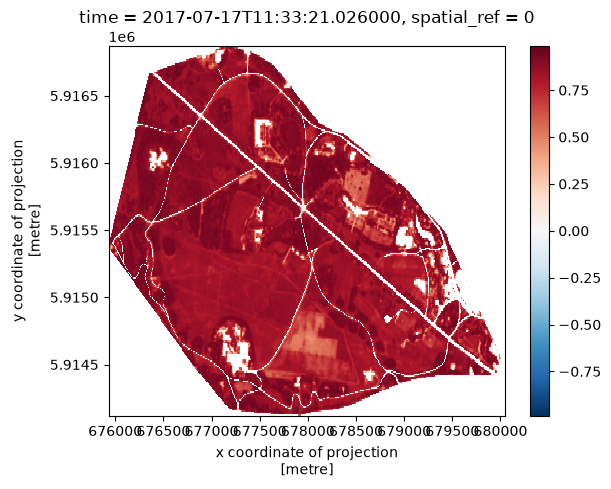

In [27]:
ndvi_map.squeeze().plot()

Great - this works for one year, now let's get it working for all 10 years

In [41]:
annual_maps = {}
results = []

for year in range(2017, 2027):

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=park.total_bounds,
        datetime=f"{year}-07-01/{year}-07-31",
        query={"eo:cloud_cover": {"lt": 80}}, #relax the cloud cover filter to <80%
    )

    items = list(search.items())

    year_ndvi_maps = []

    for item in items:

        mean_ndvi, vegetation_pixels, ndvi_map = (
            calculate_scene_ndvi(item, park_utm)
        )

        results.append({
            "year": year,
            "date": item.datetime.date(),
            "cloud_cover": item.properties["eo:cloud_cover"],
            "mean_ndvi": mean_ndvi,
            "vegetation_pixels": vegetation_pixels,
            "item_id": item.id,
        })

        year_ndvi_maps.append(ndvi_map)

    # Create the annual pixel-level composite
    if year_ndvi_maps:
        annual_maps[year] = xr.concat(
            year_ndvi_maps,
            dim="scene"
        ).mean(
            dim="scene",
            skipna=True
        )

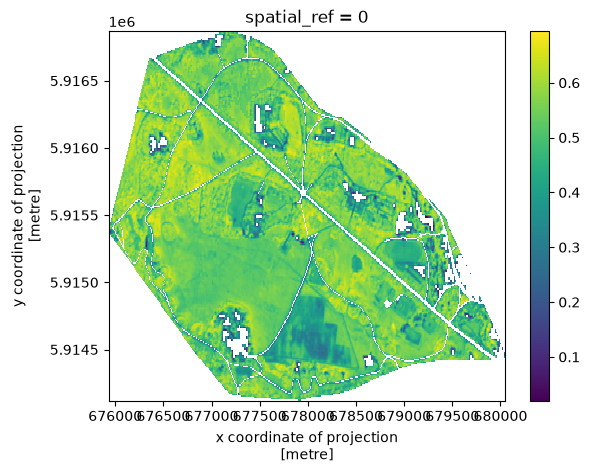

In [52]:
annual_maps[2026].squeeze().plot()

Let's plot more explicitly to control colour palettes and add park boundary overlay

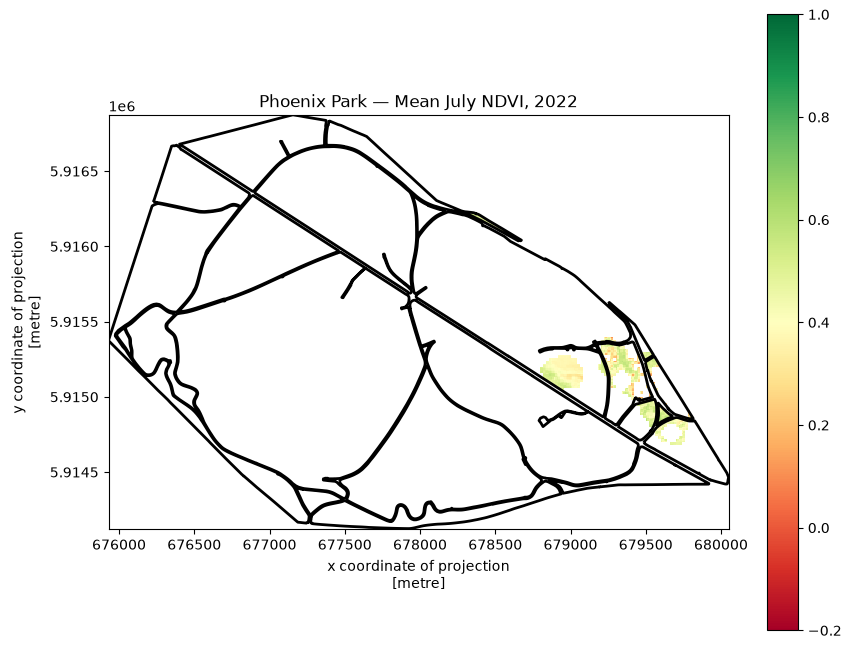

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

annual_maps[2022].squeeze().plot(
    ax=ax,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=1
)

park_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

ax.set_title("Phoenix Park — Mean July NDVI, 2022")

plt.show()

Let's write a plotting function for this - remove the x and y axis labels, and include the median ndvi value per year

In [74]:
import pandas as pd

In [75]:
results_df = pd.DataFrame(results)

annual_median_ndvi = (
    results_df
    .groupby("year")["mean_ndvi"]
    .median()
)

In [88]:
def plot_ndvi_map(year):

    fig, ax = plt.subplots(figsize=(10, 6))

    annual_maps[year].squeeze().plot(
        ax=ax,
        cmap="RdYlGn",
        vmin=-0.2,
        vmax=1
    )

    park_utm.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2
    )

    median_ndvi = annual_median_ndvi.loc[year]

    ax.set_title(f"July NDVI {year} (mean values per 10m^2)")

    ax.text(
        0.65,
        0.98,
        f"Median NDVI {year}: {median_ndvi:.2f}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

    plt.show()

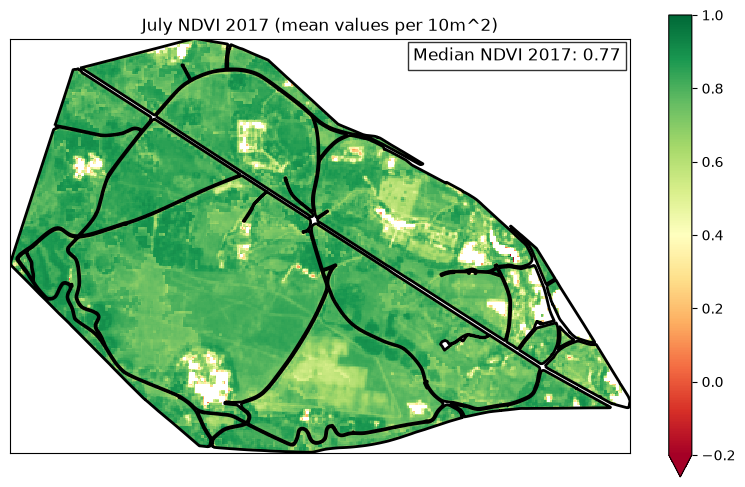

In [100]:
plot_ndvi_map(2017)